# Notebook 07 (No Augmentation, No CV) — Final Benchmarking and Evaluation

This notebook loads the single-split metrics saved by the no-augmentation / no-CV variants of
notebooks 05 and 06 (`revised_no_augmentation_no_cv/`) and performs the final benchmarking
comparison of PLS-DA, SVM, and 1D-CNN.

**Evaluation method:** Single 80/20 stratified split — results are single values, not mean +/- std.

No models are retrained here — only saved results are loaded and analyzed.

## Section 1 — Imports and Setup

In [1]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2
from sklearn.metrics import confusion_matrix

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11

os.makedirs('../../docs/figures', exist_ok=True)
os.makedirs('../../data/results/no_aug_no_cv', exist_ok=True)

print('Setup complete.')

Setup complete.


## Section 2 — Load Saved Results

Per-model metrics are loaded from `data/results/no_aug_no_cv/` — the JSON files saved by
the no-augmentation / no-CV training notebooks.

In [2]:
with open('../../data/results/no_aug_no_cv/plsda_results.json') as f:
    plsda = json.load(f)

with open('../../data/results/no_aug_no_cv/svm_results.json') as f:
    svm = json.load(f)

with open('../../data/results/no_aug_no_cv/cnn_results.json') as f:
    cnn = json.load(f)

print('Results loaded successfully.')
for name, res in [('PLS-DA', plsda), ('SVM', svm), ('1D-CNN', cnn)]:
    print(f'  {name:10s} | Accuracy={res["accuracy"]:.4f}  F1={res["f1"]:.4f}')

Results loaded successfully.
  PLS-DA     | Accuracy=0.8909  F1=0.9032
  SVM        | Accuracy=0.8727  F1=0.8889
  1D-CNN     | Accuracy=0.7909  F1=0.8000


## Section 3 — Summary Table

In [3]:
rows = []
for label, res in [('PLS-DA', plsda), ('SVM', svm), ('1D-CNN', cnn)]:
    rows.append({
        'Model':     label,
        'Accuracy':  round(res['accuracy'],  4),
        'Precision': round(res['precision'], 4),
        'Recall':    round(res['recall'],    4),
        'F1-Score':  round(res['f1'],        4),
    })

summary_df = pd.DataFrame(rows)
display(summary_df.set_index('Model'))

best_by_f1 = max(
    [('PLS-DA', plsda), ('SVM', svm), ('1D-CNN', cnn)],
    key=lambda x: x[1]['f1']
)[0]
print(f'\nHighest F1-Score: {best_by_f1}')

,Accuracy,Precision,Recall,F1-Score
Model,,,,
PLS-DA,0.8909,0.8615,0.9492,0.9032
SVM,0.8727,0.8358,0.9492,0.8889
1D-CNN,0.7909,0.8214,0.7797,0.8000



Highest F1-Score: PLS-DA


## Section 4 — Model Performance Comparison Bar Chart

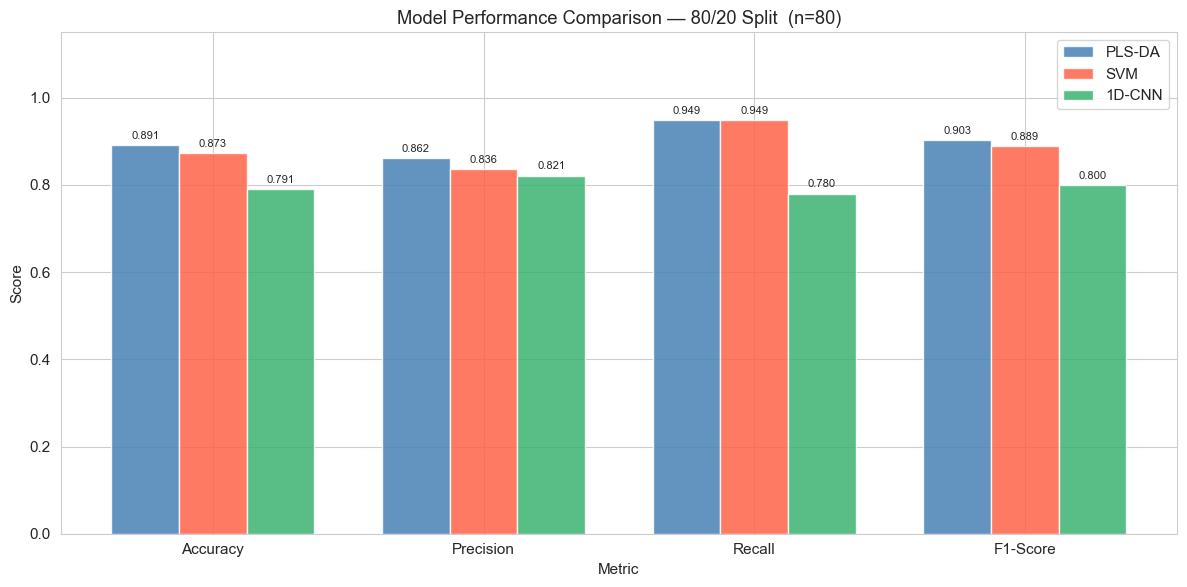

Saved: docs/figures/comparison_bar_chart_no_aug_no_cv.png


In [4]:
metrics      = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metric_keys  = ['accuracy', 'precision', 'recall', 'f1']

models_data = {
    'PLS-DA': {'vals': [plsda[k] for k in metric_keys], 'color': 'steelblue'},
    'SVM':    {'vals': [svm[k]   for k in metric_keys], 'color': 'tomato'},
    '1D-CNN': {'vals': [cnn[k]   for k in metric_keys], 'color': 'mediumseagreen'},
}

x         = np.arange(len(metrics))
bar_width = 0.25
offsets   = [-bar_width, 0, bar_width]

fig, ax = plt.subplots(figsize=(12, 6))

for (name, data), offset in zip(models_data.items(), offsets):
    bars = ax.bar(
        x + offset, data['vals'], bar_width,
        color=data['color'], alpha=0.85, label=name,
    )
    for bar, val in zip(bars, data['vals']):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f'{val:.3f}',
            ha='center', va='bottom', fontsize=8,
        )

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.15)
ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison — 80/20 Split  (n=80)')
ax.legend()
plt.tight_layout()
plt.savefig('../../docs/figures/comparison_bar_chart_no_aug_no_cv.png', bbox_inches='tight')
plt.show()
print('Saved: docs/figures/comparison_bar_chart_no_aug_no_cv.png')

## Section 5 — Confusion Matrices

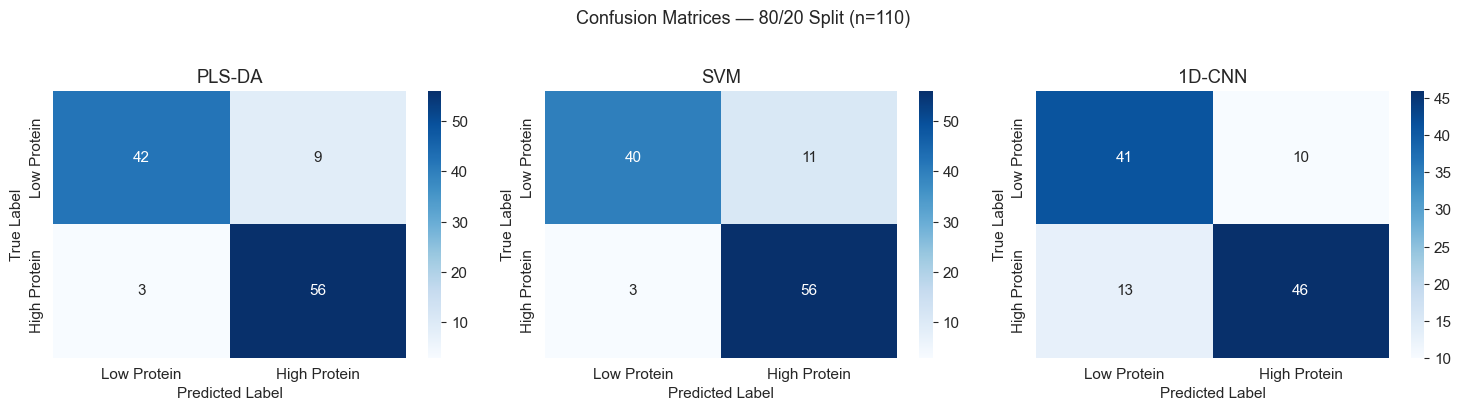

Saved: docs/figures/confusion_matrices_no_aug_no_cv.png


In [9]:
y_true_plsda = np.array(plsda['y_true'])
y_pred_plsda = np.array(plsda['y_pred'])
y_true_svm   = np.array(svm['y_true'])
y_pred_svm   = np.array(svm['y_pred'])
y_true_cnn   = np.array(cnn['y_true'])
y_pred_cnn   = np.array(cnn['y_pred'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

plot_data = [
    ('PLS-DA', y_true_plsda, y_pred_plsda),
    ('SVM',    y_true_svm,   y_pred_svm),
    ('1D-CNN', y_true_cnn,   y_pred_cnn),
]

for ax, (name, y_true, y_pred) in zip(axes, plot_data):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['Low Protein', 'High Protein'],
        yticklabels=['Low Protein', 'High Protein'],
    )
    ax.set_title(name)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

fig.suptitle('Confusion Matrices — 80/20 Split (n=110)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../../docs/figures/confusion_matrices_no_aug_no_cv.png', bbox_inches='tight')
plt.show()
print('Saved: docs/figures/confusion_matrices_no_aug_no_cv.png')

## Section 6 — McNemar's Test for Statistical Significance

McNemar's test compares pairwise classification errors on the same 16 held-out test samples.

In [6]:
def mcnemar_test(y_true, y_pred_a, y_pred_b):
    y_true   = np.array(y_true)
    y_pred_a = np.array(y_pred_a)
    y_pred_b = np.array(y_pred_b)

    b = np.sum((y_pred_a == y_true) & (y_pred_b != y_true))
    c = np.sum((y_pred_a != y_true) & (y_pred_b == y_true))

    if (b + c) == 0:
        return 0.0, 1.0

    statistic = (abs(b - c) - 1) ** 2 / (b + c)
    p_value   = 1 - chi2.cdf(statistic, df=1)
    return float(statistic), float(p_value)


pairs = [
    ('PLS-DA', 'SVM',    y_true_plsda, y_pred_plsda, y_pred_svm),
    ('PLS-DA', '1D-CNN', y_true_plsda, y_pred_plsda, y_pred_cnn),
    ('SVM',    '1D-CNN', y_true_svm,   y_pred_svm,   y_pred_cnn),
]

mcnemar_results = []
for name_a, name_b, y_true, y_pred_a, y_pred_b in pairs:
    stat, p     = mcnemar_test(y_true, y_pred_a, y_pred_b)
    significant = 'Yes' if p < 0.05 else 'No'
    mcnemar_results.append({
        'Comparison':           f'{name_a} vs {name_b}',
        'Statistic':            round(stat, 4),
        'p-value':              round(p, 4),
        'Significant (p<0.05)': significant,
    })
    p_display = f'{p:.4e}' if p < 0.0001 else f'{p:.4f}'
    print(f'{name_a} vs {name_b}: statistic={stat:.4f}  p={p_display}  significant={significant}')

mcnemar_df = pd.DataFrame(mcnemar_results)
display(mcnemar_df)

PLS-DA vs SVM: statistic=0.0714  p=0.7893  significant=No
PLS-DA vs 1D-CNN: statistic=4.0000  p=0.0455  significant=Yes
SVM vs 1D-CNN: statistic=3.0476  p=0.0809  significant=No


,Comparison,Statistic,p-value,Significant (p<0.05)
0,PLS-DA vs SVM,0.0714,0.7893,No
1,PLS-DA vs 1D-CNN,4.0000,0.0455,Yes
2,SVM vs 1D-CNN,3.0476,0.0809,No


## Section 7 — Best Model Selection

In [7]:
models_summary = {
    'PLS-DA': plsda,
    'SVM':    svm,
    '1D-CNN': cnn,
}

best_model_name = max(models_summary, key=lambda k: models_summary[k]['f1'])
best_model      = models_summary[best_model_name]

print('=' * 56)
print('  Best Model Selection (No Augmentation, No CV)')
print('=' * 56)
for name, res in models_summary.items():
    marker = ' <-- BEST' if name == best_model_name else ''
    print(f'  {name:10s} | F1: {res["f1"]:.4f}  Acc: {res["accuracy"]:.4f}{marker}')
print('=' * 56)
print(f'\nSelected best model : {best_model_name}')
print(f'F1-Score            : {best_model["f1"]:.4f}')
print(f'Accuracy            : {best_model["accuracy"]:.4f}')

  Best Model Selection (No Augmentation, No CV)
  PLS-DA     | F1: 0.9032  Acc: 0.8909 <-- BEST
  SVM        | F1: 0.8889  Acc: 0.8727
  1D-CNN     | F1: 0.8000  Acc: 0.7909

Selected best model : PLS-DA
F1-Score            : 0.9032
Accuracy            : 0.8909


## Section 8 — Save Final Results

In [8]:
summary_df.to_csv('../../data/results/no_aug_no_cv/final_comparison.csv', index=False)
print('Saved: data/results/no_aug_no_cv/final_comparison.csv')

mcnemar_df.to_csv('../../data/results/no_aug_no_cv/mcnemar_results.csv', index=False)
print('Saved: data/results/no_aug_no_cv/mcnemar_results.csv')

with open('../../data/results/no_aug_no_cv/best_model.txt', 'w') as f:
    f.write(best_model_name)
print(f'Saved: data/results/no_aug_no_cv/best_model.txt  ({best_model_name})')

Saved: data/results/no_aug_no_cv/final_comparison.csv
Saved: data/results/no_aug_no_cv/mcnemar_results.csv
Saved: data/results/no_aug_no_cv/best_model.txt  (PLS-DA)


## Section 9 — Summary

| Item | Detail |
|---|---|
| **Models compared** | PLS-DA, SVM, 1D-CNN |
| **Augmentation** | None — all models trained on raw split data only |
| **Evaluation method** | Single 80/20 stratified split (64 train / 16 test) |
| **Primary metric** | F1-Score |
| **Results location** | `data/results/no_aug_no_cv/` |
| **Figures** | Saved to `docs/figures/` with `_no_aug_no_cv` suffix |

### Key notes
- Results from this notebook can be compared with `revised_no_augmentation/07_evaluation_metrics_no_aug.ipynb`
  to see the effect of using 5-fold CV vs a single 80/20 split.
- Because only 16 test samples are evaluated, individual metric values may vary more than the
  5-fold CV mean. The single-split result depends on which 16 samples happen to be in the test set.